In [3]:
import subprocess
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.cm import ScalarMappable
import numpy as np
import re

In [6]:
def search_files(directory):
    file_list = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_list.append(os.path.join(root, file))
    return file_list

def run_cpp_curvature_calc(input_file, output_name, frame, order, sigma =1.0):
    """
    Runs the C++ curvature calculation on a specific frame.
    """
    
    executable = "/home/gabriel/MATILDA.FT/utils/post-proc/parallel-curvature-calc/prl-curvature-calc"  # Path to the C++ executable
    cmd = [executable, input_file, output_name, str(frame), str(order), str(sigma)]
    print(f"Command: {cmd}")
    try:
        subprocess.run(cmd, check=True)
        print(f"Curvature calculation for frame {frame} complete.")
    except subprocess.CalledProcessError as e:
        print(f"Error running curvature calculation: {e}")
        
def load_curvature_data(filename):
    """
    Loads the curvature data from a CSV file generated by the C++ code
    and extracts vertices, faces, and curvature information.
    """
    
    if os.path.exists(filename):
        data = pd.read_csv(filename)
        data.columns = data.columns.str.strip()  # This removes leading/trailing spaces from column names

        vertices = []
        vertex_map = {}  # To avoid duplicate vertices
        faces = []
        gaussian_curvatures = []
        mean_curvatures = []
        condition_numbers = []

        # Function to get vertex index and avoid duplicates
        def get_vertex_index(vertex_id, x, y, z, gauss_curv, mean_curv, cond_num):
            if vertex_id not in vertex_map:
                index = len(vertices)
                vertices.append([x, y, z])
                gaussian_curvatures.append(gauss_curv)
                mean_curvatures.append(mean_curv)
                condition_numbers.append(cond_num)  
                vertex_map[vertex_id] = index
                return index
            return vertex_map[vertex_id]

        # Iterate over each row in the DataFrame to build vertices and faces
        for _, row in data.iterrows():
            v1 = get_vertex_index(row['VertexID1'], row['X1'], row['Y1'], row['Z1'], row['GaussianCurvature1'], row['MeanCurvature1'], row['ConditionNumber1'])
            v2 = get_vertex_index(row['VertexID2'], row['X2'], row['Y2'], row['Z2'], row['GaussianCurvature2'], row['MeanCurvature2'], row['ConditionNumber2'])
            v3 = get_vertex_index(row['VertexID3'], row['X3'], row['Y3'], row['Z3'], row['GaussianCurvature3'], row['MeanCurvature3'], row['ConditionNumber3'])
            faces.append([v1, v2, v3])

        # Convert lists to numpy arrays
        verts = np.array(vertices)
        faces = np.array(faces)
        gaussian_curvatures = np.array(gaussian_curvatures)
        mean_curvatures = np.array(mean_curvatures)
        condition_numbers = np.array(condition_numbers)

        return verts, faces, gaussian_curvatures, mean_curvatures, condition_numbers

    else:
        print(f"File {filename} does not exist.")
        return None, None, None, None
    
def plot_curvature_surface(verts, faces, gaussian_curvatures, mean_curvatures, output_name):
    """
    Visualizes both Gaussian and Mean curvature on the surface using averaged values per face.
    """
    # Check the range of curvature values
    print("Gaussian Curvature Range:", np.min(gaussian_curvatures), np.max(gaussian_curvatures))
    print("Mean Curvature Range:", np.min(mean_curvatures), np.max(mean_curvatures))

    # Keep only the middle 80% of curvature values
    lower_gauss = np.percentile(gaussian_curvatures, 1)
    upper_gauss = np.percentile(gaussian_curvatures, 99)
    lower_mean = np.percentile(mean_curvatures, 1)
    upper_mean = np.percentile(mean_curvatures, 99)
    
    #gauss_mask = (gaussian_curvatures > lower_gauss) & (gaussian_curvatures < upper_gauss)
    #mean_mask = (mean_curvatures > lower_mean) & (mean_curvatures < upper_mean)
    
    # Clip the curvature values
    #clipped_gauss_curv = np.clip(gaussian_curvatures, lower_gauss, upper_gauss)
    #clipped_mean_curv = np.clip(mean_curvatures, lower_mean, upper_mean)
    clipped_gauss_curv = gaussian_curvatures
    clipped_mean_curv = mean_curvatures

    # Normalize the clipped curvature values
    norm_gauss_curv = (clipped_gauss_curv - np.min(clipped_gauss_curv)) / (np.max(clipped_gauss_curv) - np.min(clipped_gauss_curv))
    norm_mean_curv = (clipped_mean_curv - np.min(clipped_mean_curv)) / (np.max(clipped_mean_curv) - np.min(clipped_mean_curv))

    colormap = plt.cm.BrBG

    # Colors for each triangle face
    gauss_colors = colormap(gaussian_curvatures)
    mean_colors = colormap(mean_curvatures)
    filename = os.path.basename(output_name)
    lc_phase = re.findall(r'(nematic|smectic|isotropic)', filename)
    lc_frac = re.findall(r'frac_(0\.\d+)', filename)
    anch_str = re.findall(r'anch_str_(-?\d+\.\d+)', filename)
    fig = plt.figure(figsize=(20, 10))
    
    # Plot 1: Gaussian Curvature

    ax1 = fig.add_subplot(121, projection='3d')
    gauss_face_colors = np.mean(gauss_colors[faces], axis=1)

    gauss_mesh = Poly3DCollection(verts[faces], facecolors=gauss_colors)
    ax1.add_collection3d(gauss_mesh)
    ax1.set_title(rf'Gaussian Curvature: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    ax1.set_xlim(0, 60)
    ax1.set_ylim(0, 60)
    ax1.set_zlim(0, 60)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')

    # Plot 2: Mean Curvature
    ax2 = fig.add_subplot(122, projection='3d')
    mean_face_colors = np.mean(mean_colors[faces], axis=1)
    mean_mesh = Poly3DCollection(verts[faces], facecolors=mean_colors)
    ax2.add_collection3d(mean_mesh)
    ax2.set_title(rf'Mean Curvature: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    ax2.set_xlim(0, 60)
    ax2.set_ylim(0, 60)
    ax2.set_zlim(0, 60)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    #ax2.view_init(elev=30, azim=120)
    
    # Create a ScalarMappable object with the same colormap
    map1 = ScalarMappable(cmap=colormap)
    map1.set_array(gaussian_curvatures)  # or normalized_curvatures, depending on your preference
    map1.set_clim(vmin= -2.0, vmax=2.0)
    cbar1 = plt.colorbar(map1, ax=ax1, orientation='vertical', pad=0.1)
    cbar1.set_label('Gauss Curvature', rotation=270, labelpad=20)
    
    map2 = ScalarMappable(cmap=colormap)
    map2.set_array(mean_curvatures)  # or normalized_curvatures, depending on your preference
    map2.set_clim(vmin=-1.0, vmax=1.0)
    cbar2 = plt.colorbar(map2, ax=ax2, orientation='vertical', pad=0.1)
    cbar2.set_label('Mean Curvature', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
def scatter_curvature_surface(verts, gaussian_curvatures, mean_curvatures, condition_numbers, output_name):
    """
    Visualizes the Gaussian and Mean curvatures at each vertex using scatter plots.
    """
    # Check the range of curvature values
    print("Gaussian Curvature Range:", np.min(gaussian_curvatures), np.max(gaussian_curvatures))
    print("Mean Curvature Range:", np.min(mean_curvatures), np.max(mean_curvatures))
    print("Condition Number Range:", np.min(condition_numbers), np.max(condition_numbers))

    # Keep only the middle 98% of curvature values
    lower_gauss = np.percentile(gaussian_curvatures, 1)
    upper_gauss = np.percentile(gaussian_curvatures, 99)
    lower_mean = np.percentile(mean_curvatures, 1)
    upper_mean = np.percentile(mean_curvatures, 99)
    lower_cond, upper_cond = np.percentile(condition_numbers, [1, 99])

    
    gauss_mask = (gaussian_curvatures > lower_gauss) & (gaussian_curvatures < upper_gauss)
    mean_mask = (mean_curvatures > lower_mean) & (mean_curvatures < upper_mean)
    
    # Clip the curvature values and vertices
    gaussian_curvatures = gaussian_curvatures[gauss_mask] 
    mean_curvatures = mean_curvatures[mean_mask]
    gauss_verts = verts[gauss_mask]
    mean_verts = verts[mean_mask]

    # Use a colormap
    colormap = plt.cm.coolwarm
    filename = os.path.basename(output_name)
    lc_phase = re.findall(r'(nematic|smectic|isotropic)', filename)
    lc_frac = re.findall(r'frac_(0\.\d+)', filename)
    anch_str = re.findall(r'anch_str_(-?\d+\.\d+)', filename)

    # Plot 1: Gaussian Curvature Scatter
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(131, projection='3d')
    scatter_gauss = ax1.scatter(gauss_verts[:, 0], gauss_verts[:, 1], gauss_verts[:, 2], c=gaussian_curvatures, cmap=colormap, marker='o', s=5, vmin=-2, vmax=2) 
    fig.colorbar(scatter_gauss, ax=ax1, shrink=0.5, aspect=5)
    ax1.set_title(rf'Gaussian Curvature: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_xlim(0, 60)
    ax1.set_ylim(0, 60)
    ax1.set_zlim(0, 60)
    
    # Plot 2: Mean Curvature Scatter
    ax2 = fig.add_subplot(132, projection='3d')
    scatter_mean = ax2.scatter(mean_verts[:, 0], mean_verts[:, 1], mean_verts[:, 2], c=mean_curvatures, cmap=colormap, marker='o', s=5, vmin=-1, vmax=1)
    fig.colorbar(scatter_mean, ax=ax2, shrink=0.5, aspect=5)
    ax2.set_title(rf'Mean Curvature: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_xlim(0, 60)
    ax2.set_ylim(0, 60)
    ax2.set_zlim(0, 60)

    # Plot 3: Condition Number Scatter
    ax3 = fig.add_subplot(133, projection='3d')
    scatter_cond = ax3.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=condition_numbers, cmap=colormap, marker='o', s=5)
    fig.colorbar(scatter_cond, ax=ax3, shrink=0.5, aspect=5)
    ax3.set_title(rf'Condition Number: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Z')
    ax3.set_xlim(0, 60)
    ax3.set_ylim(0, 60)
    ax3.set_zlim(0, 60)
    plt.tight_layout()
    plt.show()   
    
def plot_curvature_histogram(gaussian_curvatures, mean_curvatures, output_name):
    """
    Plots histograms of the Gaussian and mean curvature.
    """
    # Print the amount of curvature values
    print("Gaussian Curvature Count:", len(gaussian_curvatures))
    print("Mean Curvature Count:", len(mean_curvatures))
    
    lower_gauss = np.percentile(gaussian_curvatures, 1)
    upper_gauss = np.percentile(gaussian_curvatures, 99)
    lower_mean = np.percentile(mean_curvatures, 1)
    upper_mean = np.percentile(mean_curvatures, 99)
    
    gauss_mask = (gaussian_curvatures > lower_gauss) & (gaussian_curvatures < upper_gauss)
    mean_mask = (mean_curvatures > lower_mean) & (mean_curvatures < upper_mean)
    # Print the amount of curvature values after clipping
    print("Gaussian Curvature Count (Clipped):", len(gaussian_curvatures[gauss_mask]))
    print("Mean Curvature Count (Clipped):", len(mean_curvatures[mean_mask]))
    clipped_gauss_curv = gaussian_curvatures[gauss_mask] 
    clipped_mean_curv = mean_curvatures[mean_mask]
    # Find file parameters
    filename = os.path.basename(output_name)
    lc_phase = re.findall(r'(nematic|smectic|isotropic)', filename)
    lc_frac = re.findall(r'frac_(0\.\d+)', filename)
    anch_str = re.findall(r'anch_str_(-?\d+\.\d+)', filename)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    gauss_curv_values, gauss_curv_bin_edges = np.histogram(clipped_gauss_curv, bins=100, range = (-2, 2), density=True)
    gauss_bin_centers = 0.5*(gauss_curv_bin_edges[1:] + gauss_curv_bin_edges[:-1])

    axs[0].semilogy(gauss_bin_centers, gauss_curv_values, color='firebrick',linestyle= '-', marker = "o", alpha=0.7)
    axs[0].set_title(rf'Gaussian Curvature: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    axs[0].set_xlabel('Gaussian Curvature')
    axs[0].set_ylabel('Frequency')
        
    mean_curv_values, mean_curv_bin_edges = np.histogram(clipped_mean_curv, bins=50, range = (-1, 1), density=True)
    mean_bin_centers = 0.5*(mean_curv_bin_edges[1:] + mean_curv_bin_edges[:-1])
    
    
    axs[1].semilogy(mean_bin_centers, mean_curv_values, color='teal',linestyle= '-', marker = "o", alpha=0.7)
    axs[1].set_title(rf'Mean Curvature: {lc_phase}, $\phi$ = {lc_frac}, $\Delta \chi$ = {anch_str}')
    axs[1].set_xlabel('Mean Curvature')
    axs[1].set_ylabel('Frequency')
    


    plt.tight_layout()
    plt.show()

def process_frames(input_file, output_name, frames, order, sigma):
    for frame in frames:
        csv_file = f"{output_name}{frame:02d}_order_{order}_sigma_{sigma}_curvature.csv"
        if os.path.exists(csv_file + ".gz"):
            print(f"Curvature data for frame {frame} already exists.")
            verts, faces, gaussian_curvatures, mean_curvatures, condition_numbers = load_curvature_data(csv_file)
        else:
            print(f"Calculating curvature for frame {frame}...")
            run_cpp_curvature_calc(input_file, output_name, frame, order, sigma)
            verts, faces, gaussian_curvatures, mean_curvatures, condition_numbers = load_curvature_data(csv_file)
            
        
        if verts is not None:
            #plot_curvature_surface(verts, faces, gaussian_curvatures, mean_curvatures, output_name)
            scatter_curvature_surface(verts, gaussian_curvatures, mean_curvatures, condition_numbers, output_name)
            plot_curvature_histogram(gaussian_curvatures, mean_curvatures, output_name)

Calculating curvature for frame 0...
Command: ['/home/gabriel/MATILDA.FT/utils/post-proc/parallel-curvature-calc/prl-curvature-calc', '/home/gabriel/Projects/Anchoring_Study/anch_frac_0.5/Results/lc_length_6/Avg_Density/avg_density_steps_20_smectic_lc_frac_0.5_anch_str_0.0_frame_10_rep_0.bin', '/home/gabriel/Projects/Anchoring_Study/anch_frac_0.5/Results/lc_length_6/Avg_Density/avg_density_steps_20_smectic_lc_frac_0.5_anch_str_0.0_frame_10_rep_0_frame_', '0', '3', '0.0']
Order of calculation: 3
Reading density grid data for frame: 0
Elapsed time: 134.071 s
Curvature calculation for frame 0 complete.
Gaussian Curvature Range: -2.78748 3.59683
Mean Curvature Range: -0.279202 1.98641
Condition Number Range: 22.2162 25.8474


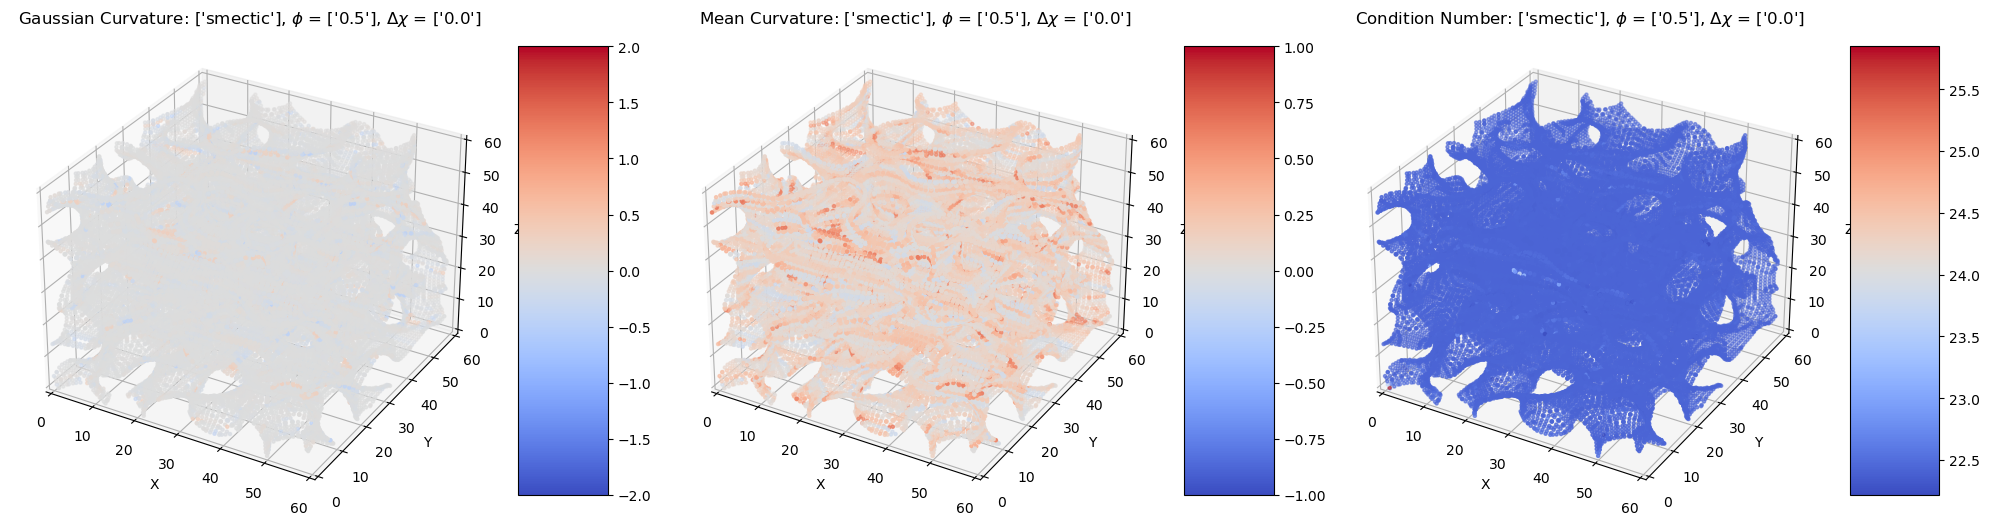

Gaussian Curvature Count: 40108
Mean Curvature Count: 40108
Gaussian Curvature Count (Clipped): 39304
Mean Curvature Count (Clipped): 39304


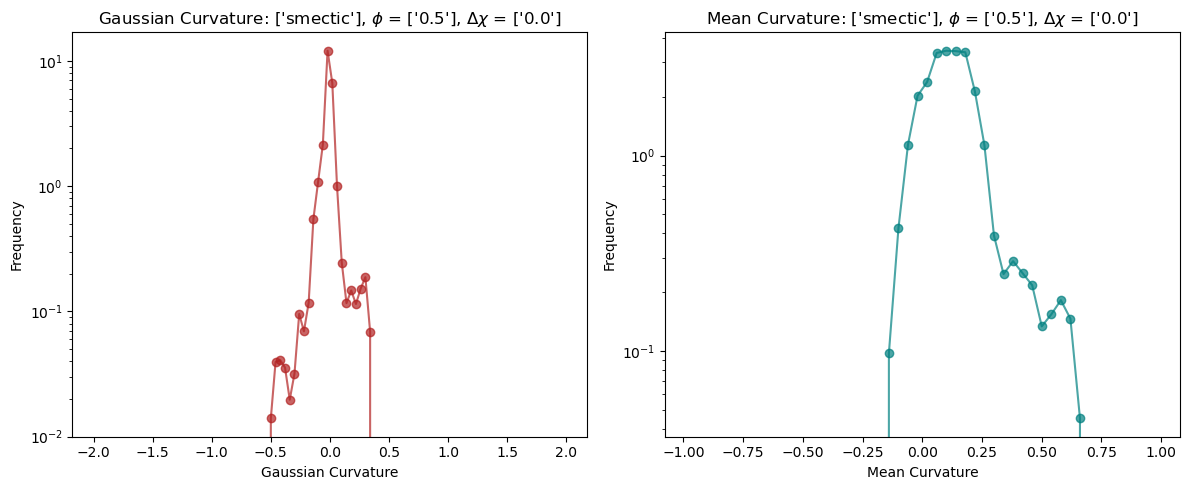

Calculating curvature for frame 0...
Command: ['/home/gabriel/MATILDA.FT/utils/post-proc/parallel-curvature-calc/prl-curvature-calc', '/home/gabriel/Projects/Anchoring_Study/anch_frac_0.5/Results/lc_length_6/Avg_Density/avg_density_steps_20_nematic_lc_frac_0.5_anch_str_0.0_frame_10_rep_0.bin', '/home/gabriel/Projects/Anchoring_Study/anch_frac_0.5/Results/lc_length_6/Avg_Density/avg_density_steps_20_nematic_lc_frac_0.5_anch_str_0.0_frame_10_rep_0_frame_', '0', '3', '0.0']
Order of calculation: 3
Reading density grid data for frame: 0
Elapsed time: 134.725 s
Curvature calculation for frame 0 complete.
Gaussian Curvature Range: -7.39114 0.81293
Mean Curvature Range: -1.03831 0.920917
Condition Number Range: 22.3331 31.2843


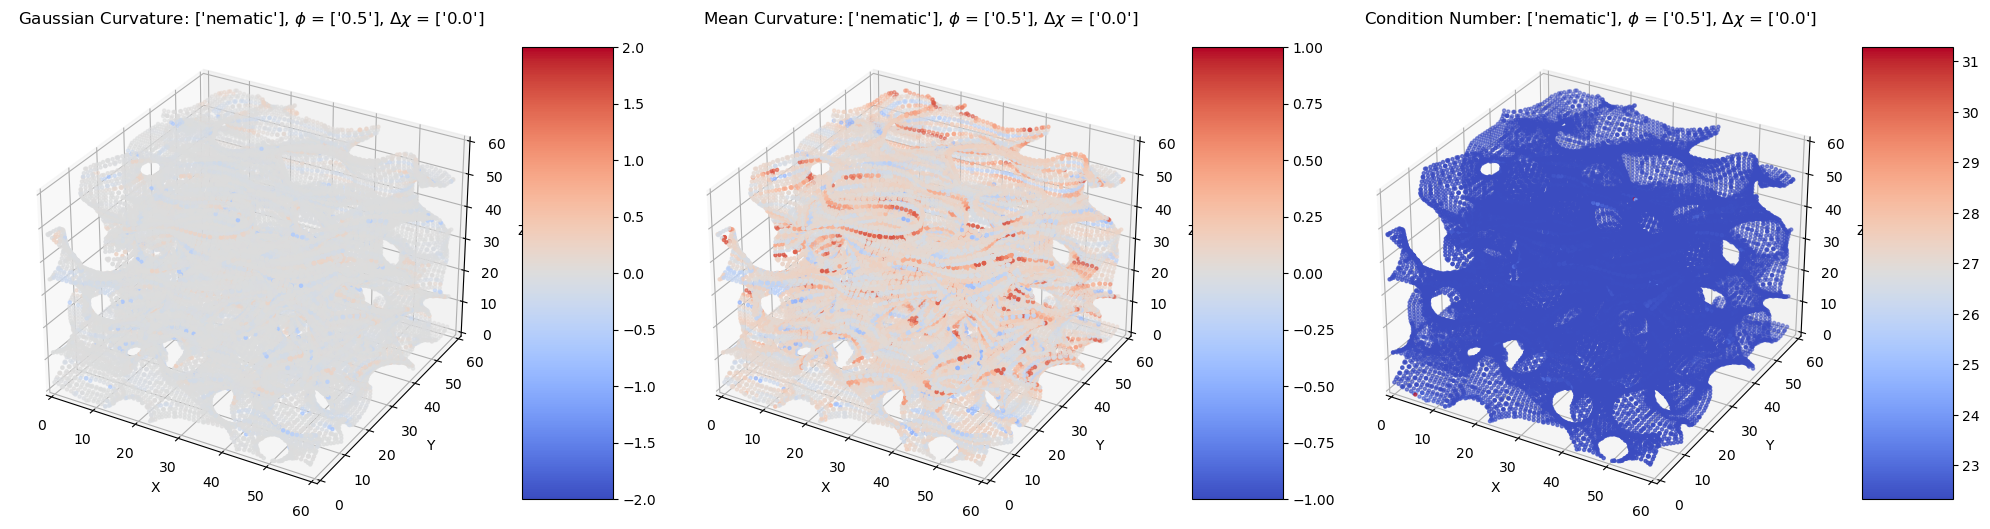

Gaussian Curvature Count: 39150
Mean Curvature Count: 39150
Gaussian Curvature Count (Clipped): 38366
Mean Curvature Count (Clipped): 38366


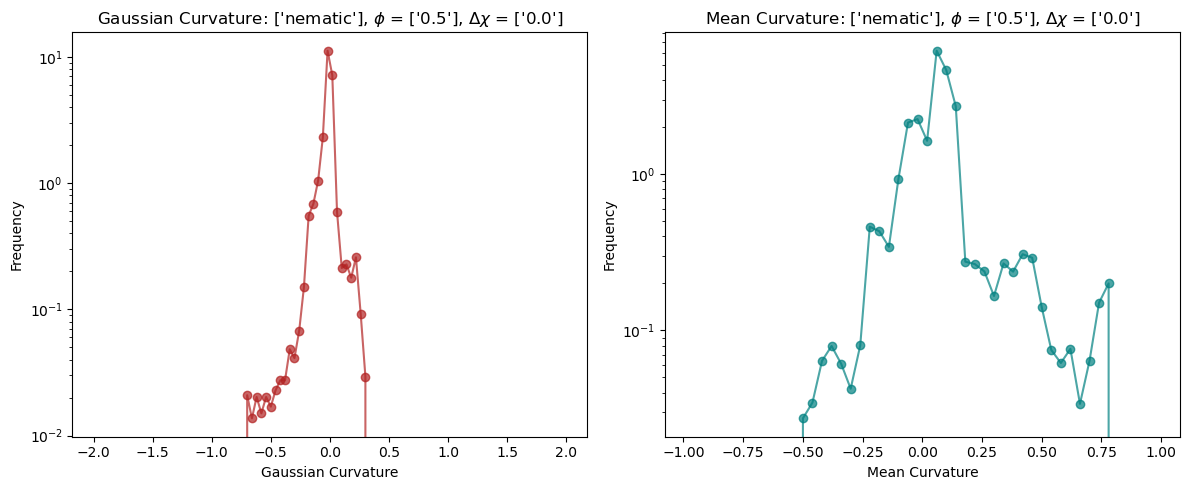

In [9]:
import re
#file_directory = "/home/gabriel/Projects/Anchoring_Study/anch_frac_0.5/Results/lc_length_6/Density"
#file_directory = "/home/gabriel/MATILDA.FT/utils/post-proc/parallel-curvature-calc"
file_directory = "/home/gabriel/Projects/Anchoring_Study/anch_frac_0.5/Results/lc_length_6/Avg_Density"
files = search_files(file_directory)
order = 3
sigma = 0.0
for file in files:
    filename = os.path.basename(file)
    directory = os.path.dirname(file)
    #pattern = re.compile(r"phase_separation_(isotropic|nematic|smectic)_lc_frac_0.3_anch_str_(-5.0|0.0|5.0)_Nb_6_rep_0_Nb_6_den.bin")
    #pattern = re.compile(r"phase_separation_nematic_lc_frac_0.7_anch_str_0.0_Nb_6_rep_0_Nb_6_den.bin")
    #pattern = re.compile("(sphere|cylinder)_density_radius_15.0_sigma_(0.0|1.0).bin")
    pattern = re.compile("avg_density_steps_20_(nematic|smectic)_lc_frac_0.5_anch_str_0.0_frame_10_rep_0.bin")
    if pattern.match(filename):
        output = os.path.join(directory, f'{filename[:-4]}_frame_')
        frames = [0]
        process_frames(file, output, frames, order, sigma)

In [9]:
print("Verts: ", verts[:10])

NameError: name 'verts' is not defined